In [6]:
import sklearn # main ML library
import numpy as np #Numerical python (works with arrays, matrices) --> for Example XB is a matrix multiplication
import matplotlib.pyplot as plt #plotting
import pandas as pd





In [7]:
data = sklearn.datasets.fetch_openml('airlines', as_frame=False)

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name airlines exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1169
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=41672

  warn(warning_msg)


In [9]:
# Convert to DataFrame for easier EDA
X = data.data
y = data.target
df = pd.DataFrame(X, columns=data.feature_names)
df['Delay'] = y  # add target column

print(df.head())

  Airline Flight AirportFrom AirportTo DayOfWeek Time Length Delay
0      CO    269         SFO       IAH         3   15    205     1
1      US   1558         PHX       CLT         3   15    222     1
2      AA   2400         LAX       DFW         3   20    165     1
3      AA   2466         SFO       DFW         3   20    195     1
4      AS    108         ANC       SEA         3   30    202     0


#EDA
1. Class balance — how many delayed vs not delayed flights?
2. Feature values — what do the values look like?
3. Missing values — is any data missing?

In [10]:
# Full EDA in pandas
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Statistics ===")
print(df.describe())

print("\n=== Class Balance ===")
print(df['Delay'].value_counts(normalize=True) * 100)

=== Shape ===
(539383, 8)

=== Data Types ===
Airline        object
Flight         object
AirportFrom    object
AirportTo      object
DayOfWeek      object
Time           object
Length         object
Delay          object
dtype: object

=== Missing Values ===
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64

=== Statistics ===
       Airline  Flight AirportFrom AirportTo DayOfWeek    Time  Length   Delay
count   539383  539383      539383    539383    539383  539383  539383  539383
unique      18    6585         293       293         7    1131     426       2
top         WN      16         ATL       ATL         4     360      80       0
freq     94097     420       34449     34440     91445   10784   13339  299119

=== Class Balance ===
Delay
0    55.455771
1    44.544229
Name: proportion, dtype: float64


#Preprocessing Pipeline
* Problem1: Convert text → numbers (Label Encoding) --> Model needs numbers to Compute Xβ
* Problem2: Put all numbers on the same scale (Normalization) --> Gradient descent works better when all features are on the same scale
* Problem3:  Numeric features stored as strings → need type conversion


In [11]:
df.head()

,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,CO,269,SFO,IAH,3,15,205,1
1,US,1558,PHX,CLT,3,15,222,1
2,AA,2400,LAX,DFW,3,20,165,1
3,AA,2466,SFO,DFW,3,20,195,1
4,AS,108,ANC,SEA,3,30,202,0


#

In [12]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split


text_cols = ["Airline", "AirportFrom", "AirportTo"]
le= LabelEncoder()
for col in text_cols:
  df[col] = le.fit_transform(df[col])

numeric_cols = ["Flight", "DayOfWeek", "Time", "Length"]
for col in numeric_cols:
  df[col] = df[col].astype(float)

#new dataset
X_clean = df.drop('Delay', axis=1).values
y_clean = df['Delay'].astype(int).values

#Normalize
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_clean)

#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_clean,
    test_size=0.2,
    random_state=42
)

print("\n=== Train/Test Split ===")
print(f"X_train: {X_train.shape} → {X_train.shape[0]:,} flights")
print(f"X_test:  {X_test.shape} → {X_test.shape[0]:,} flights")



=== Train/Test Split ===
X_train: (431506, 7) → 431,506 flights
X_test:  (107877, 7) → 107,877 flights


#Training Model


In [13]:
from sklearn.linear_model import LogisticRegression

#train the model
model= LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

**`LogisticRegression(max_iter=1000)`:**
- `max_iter=1000` → maximum number of epochs before stopping
- Without this, sklearn might stop too early and warn us

**`model.fit(X_train, y_train)`:**
- This is where **all the training happens**
- Gradient descent runs until convergence
- Model learns the best $\beta$ values

In [14]:
# --- 5.2 Look at what the model learned ---
print("=== Learned Weights (β) ===")
for feature, weight in zip(data.feature_names, model.coef_[0]):
    print(f"{feature:<15} β = {weight:.4f}  →  odds ratio = {np.exp(weight):.4f}")

print(f"\nIntercept (β₀) = {model.intercept_[0]:.4f}")

=== Learned Weights (β) ===
Airline         β = 0.5013  →  odds ratio = 1.6508
Flight          β = -0.2785  →  odds ratio = 0.7569
AirportFrom     β = 0.0967  →  odds ratio = 1.1015
AirportTo       β = 0.2449  →  odds ratio = 1.2775
DayOfWeek       β = -0.1778  →  odds ratio = 0.8371
Time            β = 1.5773  →  odds ratio = 4.8421
Length          β = 0.8626  →  odds ratio = 2.3693

Intercept (β₀) = -1.5454


# Interpreting the Learned Weights
* The Model Learned These β Values: --> Intercept (β₀) = -1.5454  ← baseline (when all features = 0)

###time
* β = 1.5773  →  odds ratio = 4.84 --> "Later departure times make delays 4.84x more likely"
Makes total sense — flights later in the day carry delays from earlier flights!

###Length
* β = 0.8626  →  odds ratio = 2.37--> "Longer flights make delays 2.37x more likely"
Longer flights = more things can go wrong

###Airline

* β = 0.5013  →  odds ratio = 1.65 --> "Some airlines make delays 1.65x more likely than others"

###DayOfWeek - Negative Effect
* β = -0.1778  →  odds ratio = 0.84 --> Later days of the week make delays slightly less likely"
Odds ratio < 1 → reduces probability of delay








In [20]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of delay

In [23]:
print("\n=== Sample Predictions ===")
print(f"{'Flight':<10} {'P(Delay)':<12} {'Predicted':<12} {'Actual'}")
print("-" * 45)
for i in range(5):
  print(f"{i:<10} {y_prob[i]:<12.3f} {y_pred[i]:<12} {y_test[i]}")


=== Sample Predictions ===
Flight     P(Delay)     Predicted    Actual
---------------------------------------------
0          0.423        0            1
1          0.493        0            1
2          0.370        0            1
3          0.435        0            0
4          0.531        1            1


**`model.predict()`:**
- Applies threshold of 0.5 → returns 0 or 1
- This is $\hat{Y}$ — the final prediction

**`model.predict_proba()`:**
- Returns the actual **probability** before thresholding
- This is $P(Y=1|X)$ — the sigmoid output
- `[:, 1]` → we want probability of class 1 (delayed)


**'The Key Observation'**
* Flights 0, 1, 2 are all False Negatives — the model predicted no delay but there actually was one. Their probabilities (0.423, 0.493, 0.370) are all close to 0.5... meaning the model was uncertain.

* This is also why threshold matters! If we lowered it to 0.4:
- Flight 0 (0.423) → would now predict 1 ✅
- Flight 3 (0.435) → would now predict 1 ❌ (false alarm)

Higher recall but lower precision (Tradeoff)

#Model Evaluation


=== Confusion Matrix ===
                 Predicted 0    Predicted 1
Actual 0 (No):       45793          14086
Actual 1 (Yes):      30677          17321

=== Core Metrics ===
Accuracy:  0.585
Precision: 0.552
Recall:    0.361
F1 Score:  0.436


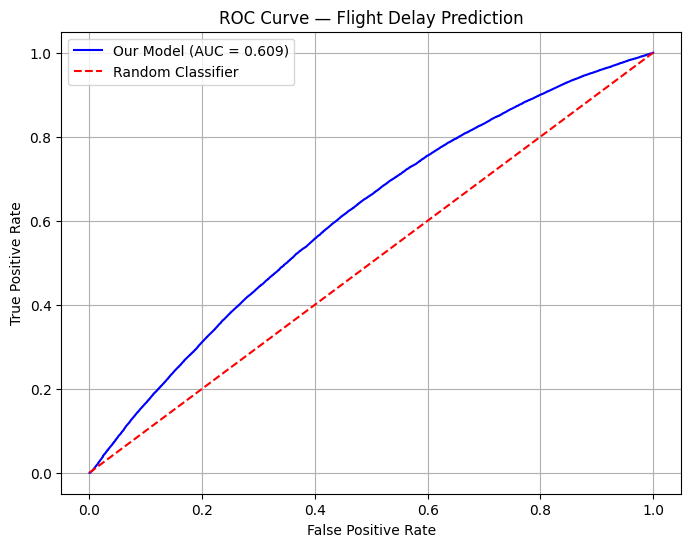

In [25]:
from sklearn.metrics import (confusion_matrix,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_curve,
                             roc_auc_score)

# --- 6.1 Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
print("=== Confusion Matrix ===")
print(f"                 Predicted 0    Predicted 1")
print(f"Actual 0 (No):      {cm[0][0]:>6}         {cm[0][1]:>6}")
print(f"Actual 1 (Yes):     {cm[1][0]:>6}         {cm[1][1]:>6}")

# --- 6.2 Core Metrics ---
print("\n=== Core Metrics ===")
print(f"Accuracy:  {(cm[0][0]+cm[1][1])/cm.sum():.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.3f}")

# --- 6.3 ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Our Model (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Flight Delay Prediction')
plt.legend()
plt.grid(True)
plt.show()


###Report

* FN (30,677) is very high — the model is missing a lot of real delays!

* Recall of 0.361 is the biggest concern — missing 64% of real delays is problematic in a real airline system!


* Better than random (0.5) but far from perfect (1.0). The curve is only slightly above the diagonal — model is weakly separating delayed from non-delayed flights.


- "Its relative simplicity makes it a high-bias and low-variance model, so it may not perform well when the decision boundary is not linear"


* (regularization, removal of features, etc.) will have  marginal improvements because the core problem is that logistic regression is too simple for this data.




